# Phase 1: Operational states

This notebook identifies the train's basic **operational states**: *standing,
accelerating, cruising, braking*, directly from the data, and checks whether they make
physical sense.

The important design choice: states were defined from the train's **motion only**
(speed and acceleration), deliberately keeping the air-brake/pressure sensors out of
that definition. This keeps those sensors as *independent evidence* for Phase 2, preventing
**leakage**.

In [6]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = ROOT / "results" / "tables"
P1 = ROOT / "results" / "plots" / "phase1"
P2 = ROOT / "results" / "plots" / "phase2"
LOGS = ROOT / "logs"
pd.set_option("display.max_columns", 40)


## 1. From raw sensors to 10-second windows

The train logs ~100 sensors once per second for a year. Each non-overlapping
**10-second window** was summarised (average speed, how much speed changed, etc.).
The 10-second window is the unit of analysis.

Instead of 30 million raw rows, ~1.5 million tidy windows are used,
each describing a short slice of driving.

This is a standard, lossless-enough summarisation; window length
(10 s) was fixed early in the project.

## 2. How many states are there?

Windows were grouped by motion using two independent methods
(**k-means** and **hierarchical clustering**), and candidate group-counts were scored with
**silhouette**, **Davies–Bouldin**, and **stability (bootstrap ARI)** — see the
[Glossary in README.md](../README.md#glossary) for plain-language definitions.

,k,silhouette,davies_bouldin,kmeans_vs_hier_ari,gmm_bic,gmm_aic
0,2,0.476,0.999,NaN,-999075.756,-1000506.287
1,3,0.535,1.196,0.811,-1088827.367,-1090977.116
2,4,0.567,1.091,0.766,-1210763.741,-1213632.707
3,5,0.587,0.990,NaN,-1321646.583,-1325234.767
4,6,0.605,0.945,NaN,-1375693.136,-1380000.537


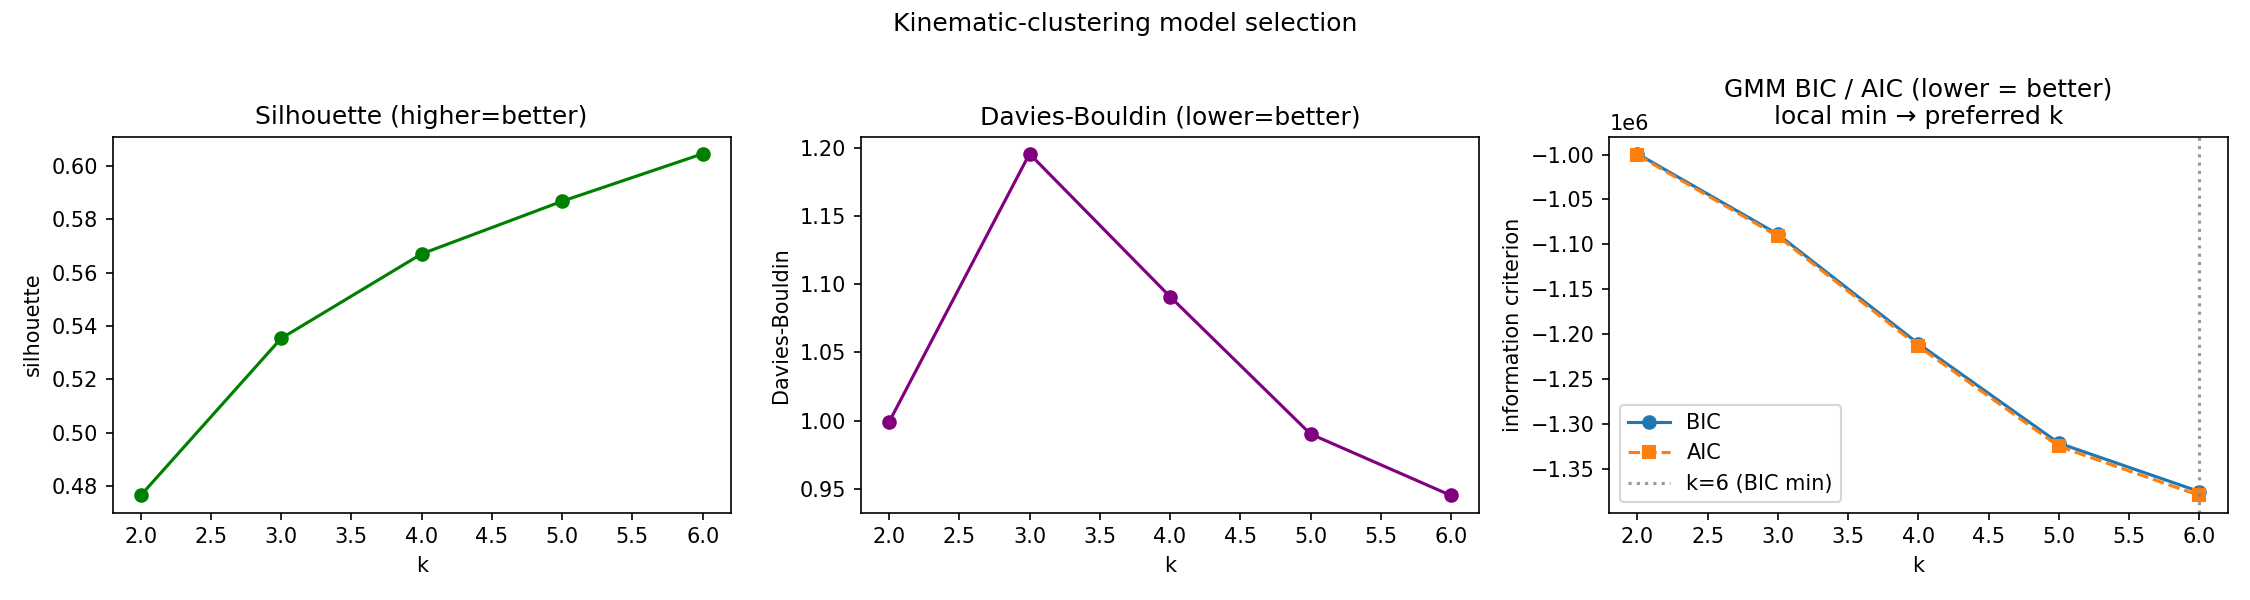

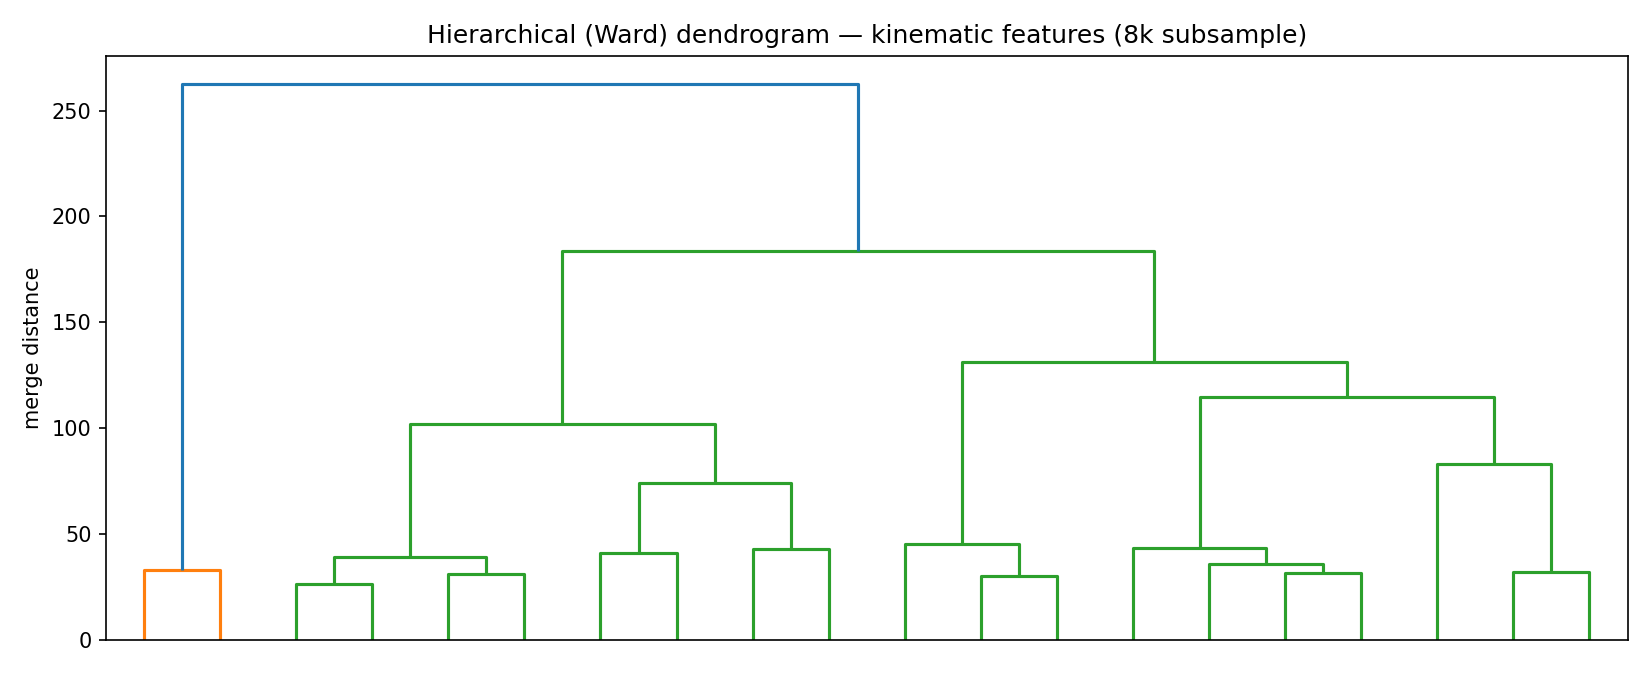

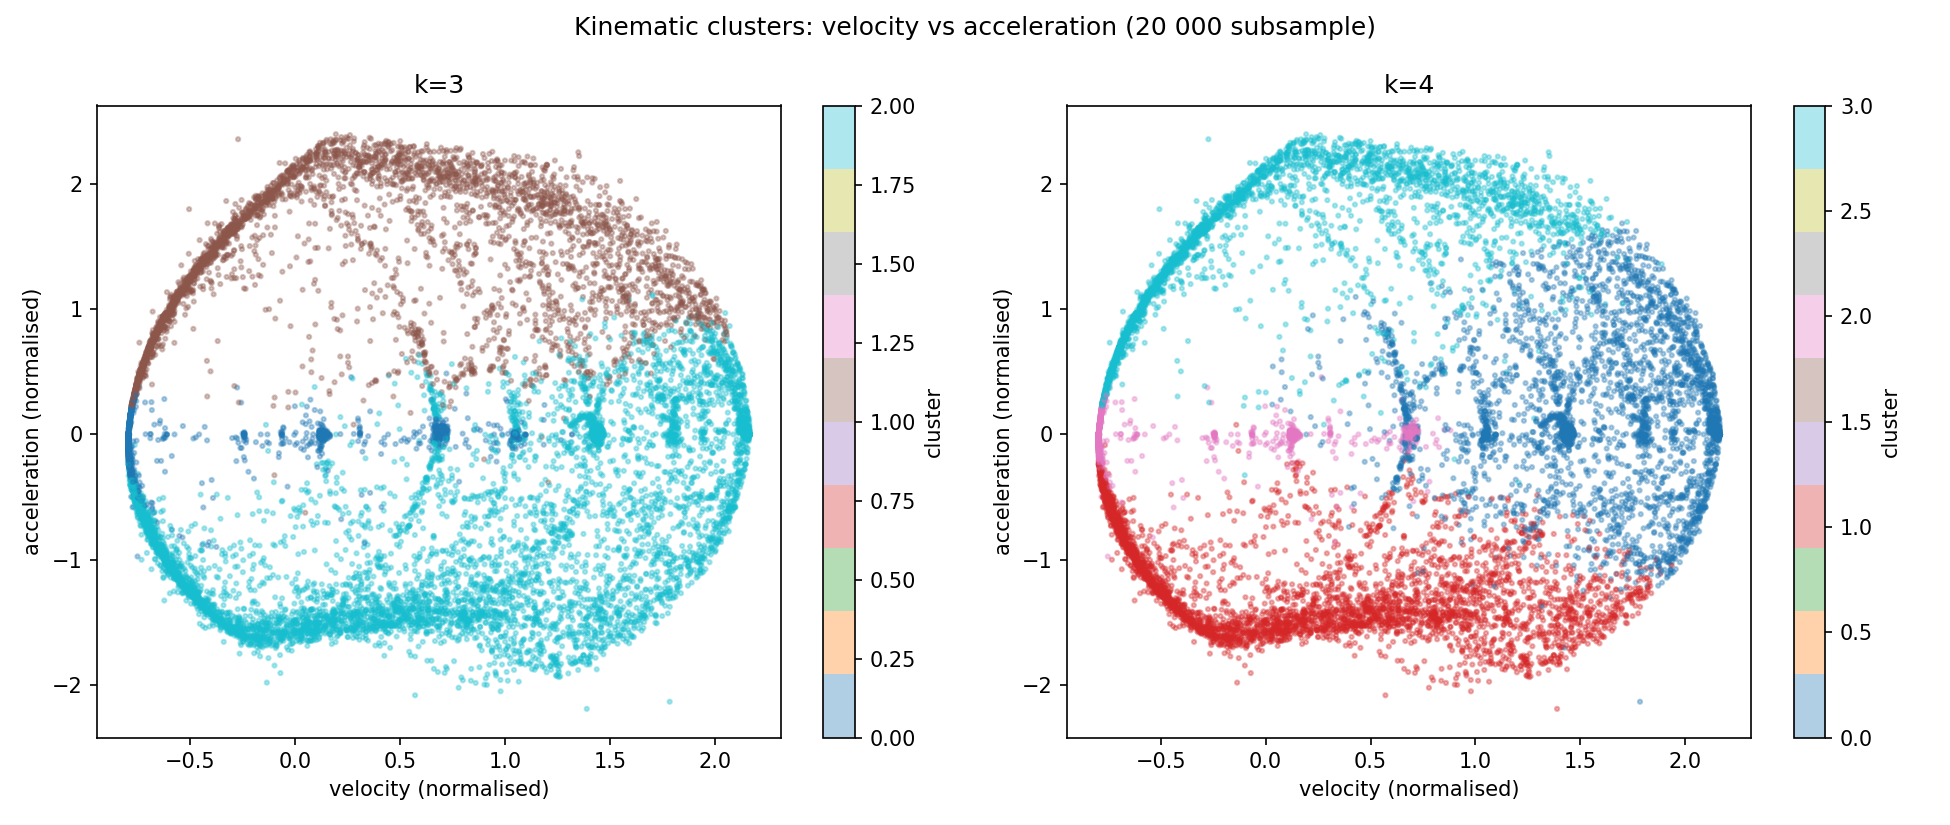

In [7]:
display(pd.read_csv(TABLES / "phase1_kselection.csv").round(3))
display(Image(filename=str(P1 / "kinematic_kselection.png")))
display(Image(filename=str(P1 / "dendrogram.png")))
display(Image(filename=str(P1 / "kinematic_vel_accel_scatter.png")))

- **Silhouette** keeps rising with k - no unique peak, so silhouette alone cannot choose k.
- **Davies–Bouldin** penalises k=3 hard: at three groups, *cruising* and *accelerating* merge into one ambiguous cluster, inflating the score.
- **GMM BIC/AIC** decreases monotonically, "more Gaussian components always fit better" statistically. There is no interior minimum. However, the drop from k=3→k=4 is the **largest single step** (−122 000 BIC units), while gains after k=4 shrink sharply (k=5→k=6 is only −54 000). This means k=4 is where the data yields the most structure per added component.

**k=4** was chosen because (a) it maps exactly onto the four physically interpretable states (standing / accelerating / cruising / braking), (b) the groups are stable under bootstrap resampling (ARI ≈ 0.77), and (c) the BIC marginal-gain pattern is consistent with k=4 being a natural breakpoint. Beyond k=4, extra clusters have no physical meaning.

#### Note
There seem to be some interesting structure in the velocity/accelerattion spread which could be explored further. A cycle (i.e. standing - accelerating - cruising - braking - standing) typically follows some typical curve in this 2D-Space. There are outliers which are not on thecurve and could hold some valuable information. This will not be researched here but the plot motivates further work here.

## 3. The four operational states

Each group was named from its physical profile (median speed and
acceleration).

,n,pct,median_velocity,median_accel
state,,,,
standing,717211,48.12,0.0000,0.0000
accelerating,213807,14.34,0.3046,0.0410
cruising,257471,17.27,0.8421,0.0019
braking,302008,20.26,0.3432,-0.0327


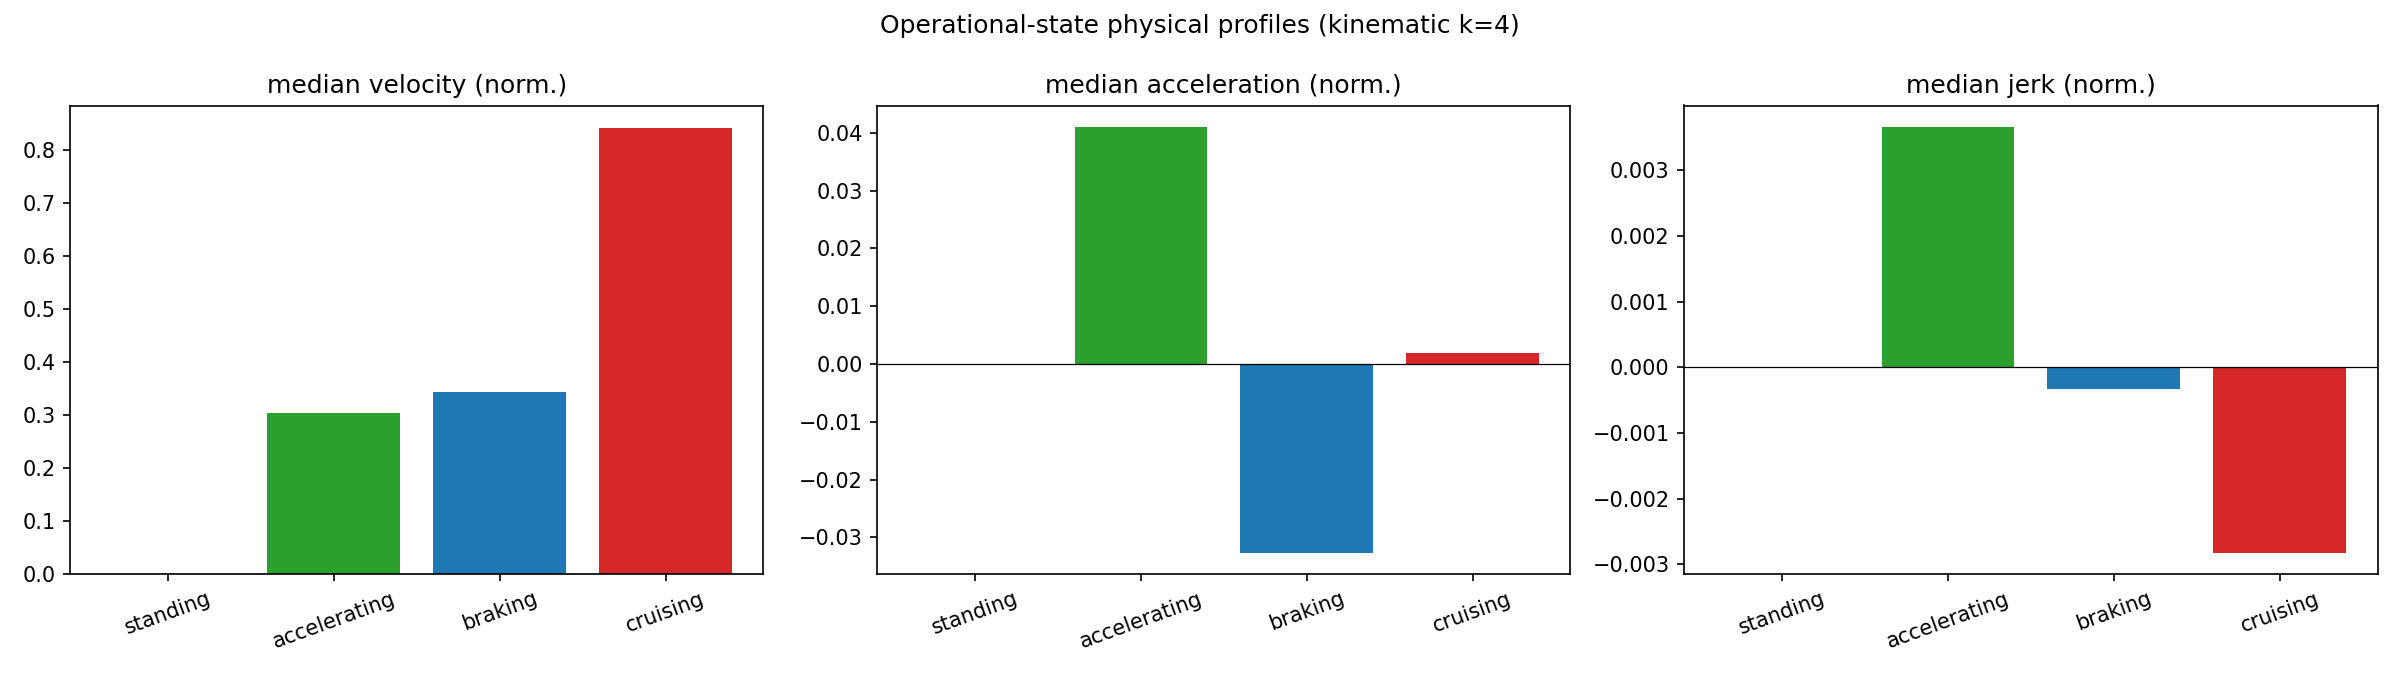

In [8]:
display(pd.read_csv(TABLES / "phase1_state_summary.csv", index_col=0).round(4))
display(Image(filename=str(P1 / "state_profiles.png")))

**What it means:**
- **standing** - not moving (~48% of the time).
- **accelerating** - speed rising (positive acceleration, ~14%).
- **cruising** - high steady speed (~17%).
- **braking** - speed falling (negative acceleration, ~20%).

Crucially, **braking now means *actually slowing down*** (negative acceleration). Often times in the data the train is standing with an engaged brake, which should not be labeled as a braking event.

Clusters are interpretable and separated.

## 4. The "held brake" discovery 

**What was done:** an earlier version included the brake-pressure sensors when defining the
states. That made a *stationary train holding its brake* (at a station) look like
"braking", because the brake pressure is high even though the train isn't moving. Defining
states from motion only fixes this. The useful information was also kept as a **sub-label**
of standing: `standing_braked` vs `standing_idle`.

In [9]:
print("Old-state vs new-state cross-tab (how windows were relabelled):")
display(pd.read_csv(TABLES / "phase1_new_vs_old_states.csv", index_col=0))

Old-state vs new-state cross-tab (how windows were relabelled):


,accelerating,braking,cruising,standing
old_state,,,,
braking,80226,104908,519,46723
cruising,133579,196610,256950,46422
standing,2,490,2,624066


The old "braking" group was contaminated - a large
chunk of it was really *standing* (brake held) or even *accelerating*. The new motion-based
states separate these correctly.

This necessary change improved Phase 2's braking analysis, which is now about genuine decelerations.

## 5. How the train moves between states

**What was done:** transition probabilities were measured (how often each state follows another) and dwell times (how long the train typically stays in each state).

,mean,std,count
state,,,
standing,54.2,641.0,132245
accelerating,17.1,5.0,124901
cruising,20.8,10.6,123545
braking,23.8,7.2,127055


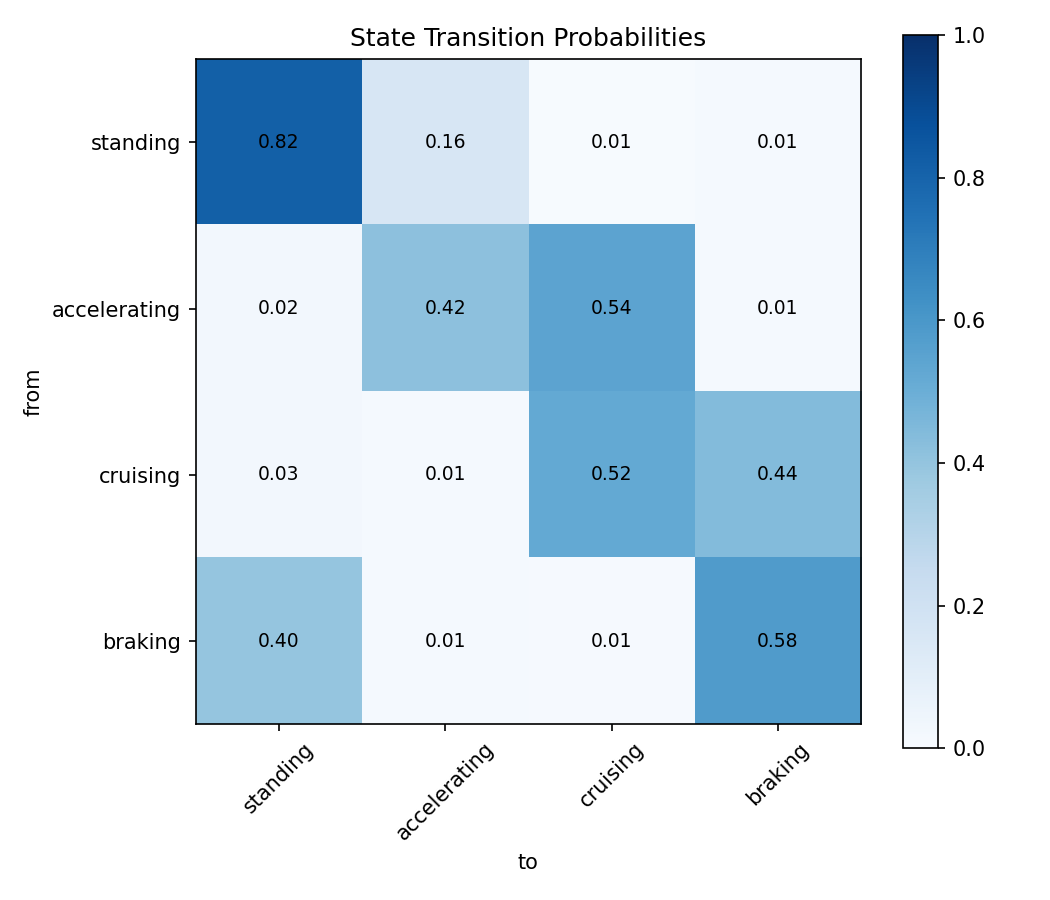

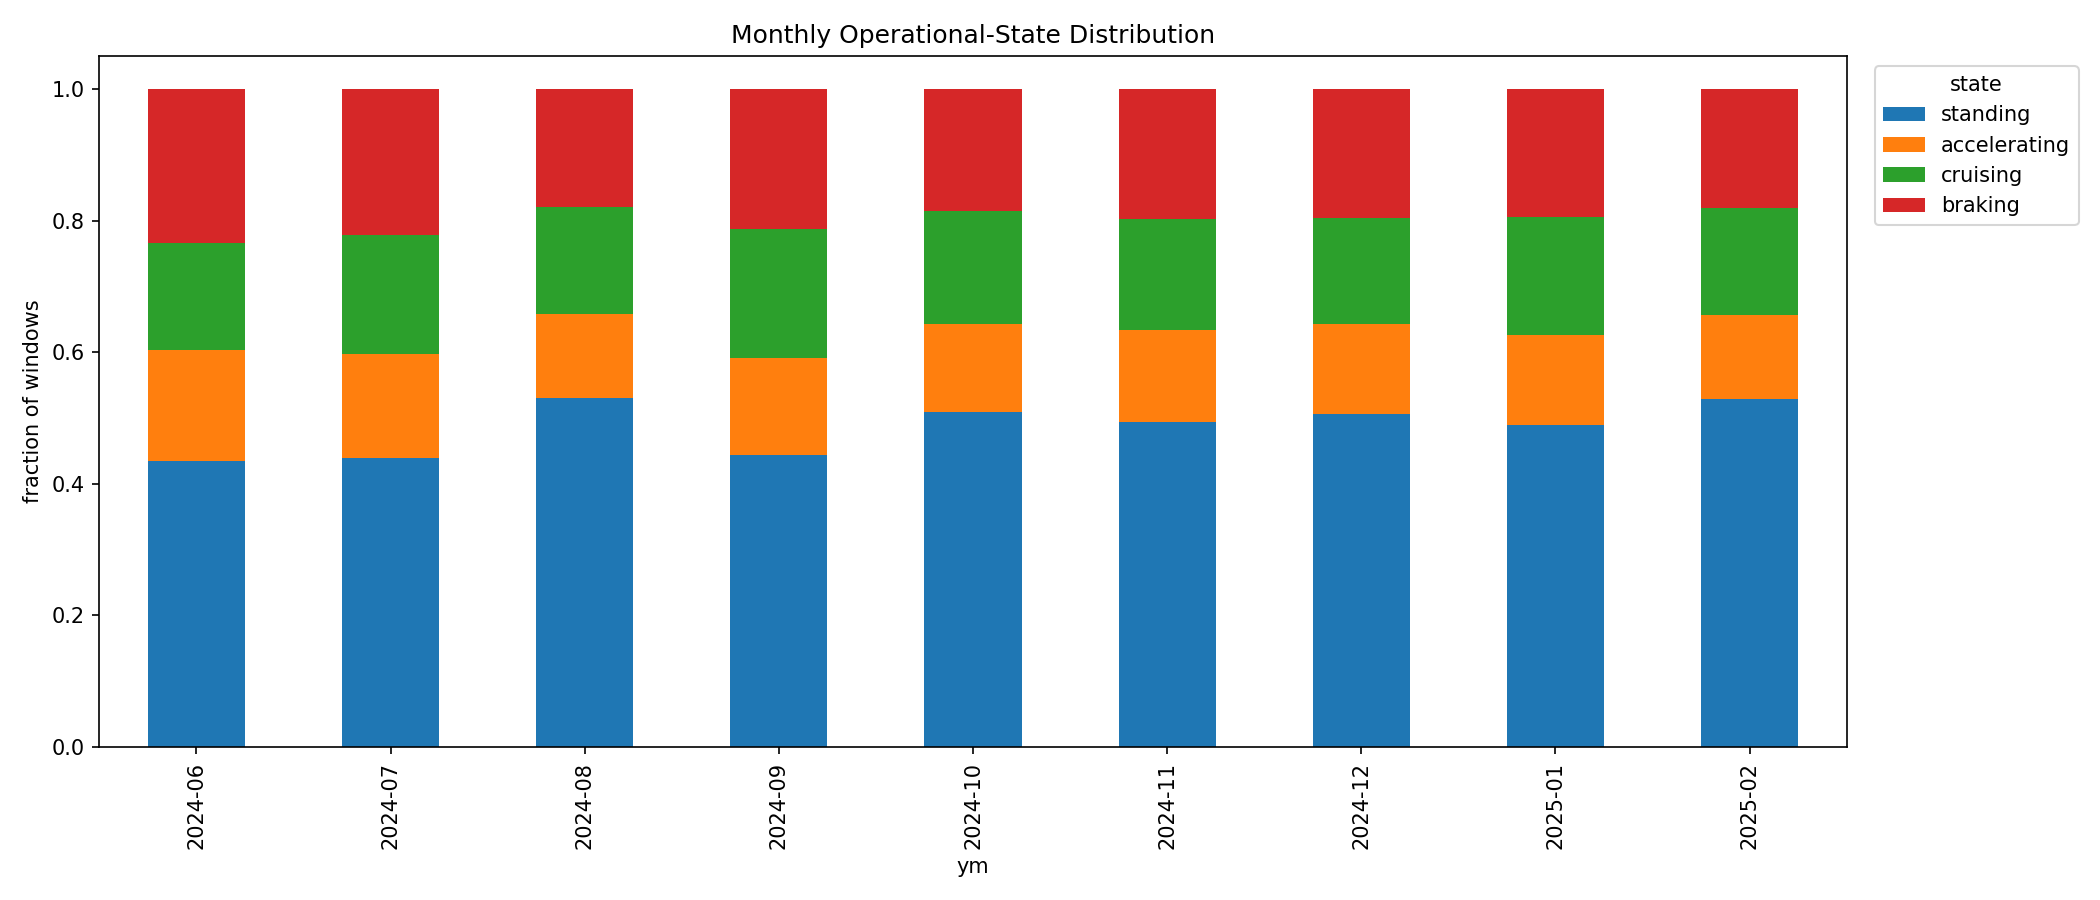

In [10]:
display(pd.read_csv(TABLES / "dwell_times.csv", index_col=0).round(1))
display(Image(filename=str(P1 / "transition_diagram.png")))
display(Image(filename=str(P1 / "state_distribution_by_month.png")))

The sequence matches normal metro operation
(stop → accelerate → cruise → brake → stop), and the mix of states is stable month to
month. This gives confidence in the choices made. The pattern is descriptive and consistent across the year.

Plain-language definitions of every method used in this notebook are in the
**[Glossary section of README.md](../README.md#glossary)**.